In [4]:
import torch
import os  
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset,random_split
import torch.nn as nn
from PIL import Image
import transformers
from transformers import ViTImageProcessor, ViTForImageClassification 
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
pip show transformers

Name: transformers
Version: 5.5.0
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: C:\Users\dffgg\anaconda3\Lib\site-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [7]:
import os
os.chdir('cataract dataset/')
print(os.getcwd())
print(os.listdir())

C:\Users\dffgg\Desktop\VGG19\cataract dataset
['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal', 'output.pdf']


In [9]:
processor= ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

In [10]:
folder="cataract dataset/"
normal_dir= "normal"
cataract_dir="cataract"

In [11]:
class EyeDataset(Dataset):
    def __init__(self, folder):
        self.images = []
        self.labels = []
        
        # These lines need to be indented inside __init__ to access self
        normal_path = os.path.join(normal_dir)
        for img in os.listdir(normal_path):
            self.images.append(os.path.join(normal_path, img))
            self.labels.append(0)
        cataract_path = os.path.join(cataract_dir)
        for img in os.listdir(cataract_path):
            self.images.append(os.path.join(cataract_path, img))
            self.labels.append(1) 
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")  # Fixed typo: return_tensirs -> return_tensors
        image_tensor = inputs["pixel_values"].squeeze(0)
        label = torch.tensor(self.labels[index])
        return image_tensor, label

In [12]:
dataset = EyeDataset(folder)
total= len(dataset)
train_size= int(0.6*total)
val_size= int(0.2*total)
test_size= total - train_size - val_size
train_data, val_data, test_data= random_split(dataset, [train_size, val_size, test_size], generator= torch.Generator().manual_seed(42))
train_loader= DataLoader(train_data, batch_size=8, shuffle=True)
val_loader= DataLoader(val_data, batch_size=8)
test_loader= DataLoader(test_data, batch_size=8)
print("Total iamges:", total)
print("Train images:", train_size)
print("Test images:", test_size)
print("Val images:", val_size)

Total iamges: 2112
Train images: 1267
Test images: 423
Val images: 422


In [13]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
model= ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=2, ignore_mismatched_sizes=True)
model.to(device)

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [14]:
loss_function= nn.CrossEntropyLoss()
optimizer= optim.AdamW(model.parameters(), lr=2e-5)
epochs= 5
for epoch in range (epochs):
    model.train()
    total_loss= 0
    for images, labels in train_loader:
        images= images.to(device)
        labels= labels.to(device)
        optimizer.zero_grad()
        outputs= model(images).logits
        loss= loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss +=loss.item()
        print("epoch:", epoch+1)
        print("loss:", total_loss/len(train_loader))

epoch: 1
loss: 0.004327191871667058
epoch: 1
loss: 0.00812124418762495
epoch: 1
loss: 0.011910662711041528
epoch: 1
loss: 0.014718594791004493
epoch: 1
loss: 0.01704676571132252
epoch: 1
loss: 0.01883511723212476
epoch: 1
loss: 0.02113790332146411
epoch: 1
loss: 0.022468835958894692
epoch: 1
loss: 0.023824726073247083
epoch: 1
loss: 0.02496201259160192
epoch: 1
loss: 0.026301167015009706
epoch: 1
loss: 0.0266409011194541
epoch: 1
loss: 0.0270122192893763
epoch: 1
loss: 0.02744028907058374
epoch: 1
loss: 0.029882261189837125
epoch: 1
loss: 0.03381526055482199
epoch: 1
loss: 0.03484143820479981
epoch: 1
loss: 0.03532710106773946
epoch: 1
loss: 0.03590213453526017
epoch: 1
loss: 0.03636837668670048
epoch: 1
loss: 0.03654204611227198
epoch: 1
loss: 0.03879425709821143
epoch: 1
loss: 0.039437359304360625
epoch: 1
loss: 0.04328524286173425
epoch: 1
loss: 0.043433188982073614
epoch: 1
loss: 0.04406684277426896
epoch: 1
loss: 0.044174388824206476
epoch: 1
loss: 0.044580641852797205
epoch: 1
lo

In [15]:
import torch.nn as nn
model.eval()
correct=0
total=0
test_loss = 0.0
loss_function = torch.nn.CrossEntropyLoss()
with torch.no_grad():
    for images, labels in test_loader:
        images= images.to(device)
        labels= labels.to(device)
        outputs= model(images).logits
        loss= loss_function(outputs, labels)
        test_loss+= loss.item()* images.size(0)
        predictions= torch.argmax(outputs, dim=1)
        correct+=(predictions == labels). sum().item()
        total += labels.size(0)
print("test accuracy:", correct/total)
print("Loss accuracy:", test_loss/total)


test accuracy: 0.9574468085106383
Loss accuracy: 0.1889299661535924


In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()
y_test, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch   # change if using dict
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        y_test.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_test, y_pred)

In [16]:
folder_path=r"C:\Users\dffgg\Desktop\VGG19\test_img"
class_names=["normal","cataract"]
model.eval()
for img_name in os.listdir(folder_path):
    img=Image.open(os.path.join(folder_path,img_name)).convert("RGB")
    inputs=processor(img, return_tensors="pt").to(device)
    with torch.no_grad():
        pred= model(**inputs).logits.argmax(-1).item()
        print(img_name, class_names[pred])
    

cataract fundus img.png cataract
cataract fundus img2.png cataract
cataract fundus img3.png cataract
cataract fundus img4.png cataract
Normal fundus img 2.png normal
Normal fundus img 3.png normal
Normal fundus img.png normal
Normal fundus img4.png normal


In [17]:
# First import the necessary libraries
from sklearn.metrics import precision_recall_fscore_support, classification_report

# Initialize lists to store all predictions and true labels
all_predictions = []
all_labels = []

# Set model to evaluation mode
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Get model predictions
        outputs = model(images).logits
        predictions = torch.argmax(outputs, dim=1)
        
        # Store predictions and labels for metric calculation
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
accuracy = sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)
print(f"Test accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1 score
# Now this function call will work because we imported it at the top
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# For a more detailed report including per-class metrics
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_predictions))

Test accuracy: 0.9574
Precision: 0.9609
Recall: 0.9574
F1 Score: 0.9574

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       220
           1       0.92      1.00      0.96       203

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



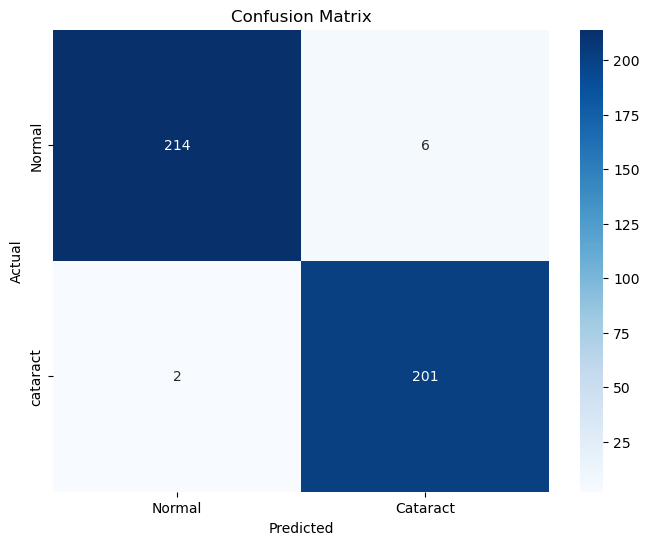

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=["Normal","Cataract"],  # Adjust these labels based on your classes
           yticklabels=["Normal","cataract"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("output.pdf")
plt.show()

In [17]:
import os
print(os.getcwd())


C:\Users\dffgg\Desktop\VGG19\cataract dataset


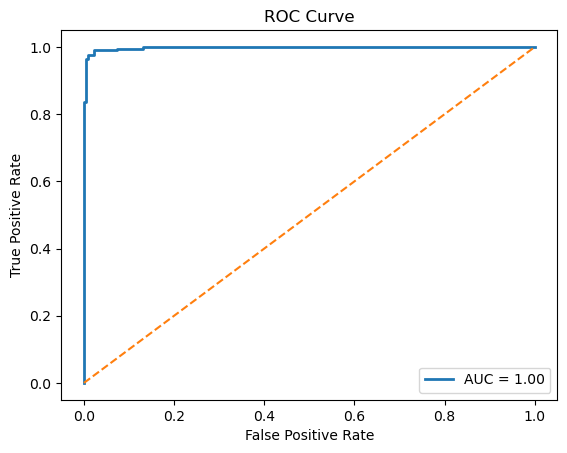

AUC: 0.9979847738468428


In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).logits
        
        # ✅ Convert logits → probabilities
        probs = torch.softmax(outputs, dim=1)[:, 1]   # class 1 = cataract
        
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

# ✅ ROC calculation
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# ✅ Plot
plt.figure()
plt.plot(fpr, tpr, lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)

In [20]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 5

for epoch in range(epochs):
    # TRAINING
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).logits
            loss = loss_function(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Train Loss=0.0027, Train Acc=1.0000, Val Loss=0.1853, Val Acc=0.9621
Epoch 2: Train Loss=0.0004, Train Acc=1.0000, Val Loss=0.1915, Val Acc=0.9597
Epoch 3: Train Loss=0.0003, Train Acc=1.0000, Val Loss=0.1975, Val Acc=0.9621
Epoch 4: Train Loss=0.0002, Train Acc=1.0000, Val Loss=0.2032, Val Acc=0.9621
Epoch 5: Train Loss=0.0002, Train Acc=1.0000, Val Loss=0.2080, Val Acc=0.9621


In [21]:
# First import the necessary libraries
from sklearn.metrics import precision_recall_fscore_support, classification_report

# Initialize lists to store all predictions and true labels
all_predictions = []
all_labels = []

# Set model to evaluation mode
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Get model predictions
        outputs = model(images).logits
        predictions = torch.argmax(outputs, dim=1)
        
        # Store predictions and labels for metric calculation
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
accuracy = sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)
print(f"Test accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1 score
# Now this function call will work because we imported it at the top
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# For a more detailed report including per-class metrics
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_predictions))

Test accuracy: 0.9811
Precision: 0.9813
Recall: 0.9811
F1 Score: 0.9811

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       220
           1       0.97      0.99      0.98       203

    accuracy                           0.98       423
   macro avg       0.98      0.98      0.98       423
weighted avg       0.98      0.98      0.98       423



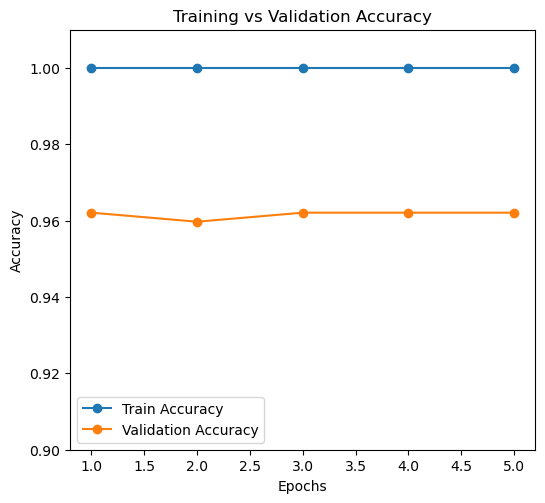

In [31]:
import matplotlib.pyplot as plt

epochs_range = range(1, 6)

plt.figure(figsize=(6,12))

# ✅ Accuracy Graph (TOP)
plt.subplot(2,1,1)
plt.plot(epochs_range, train_accs[0:5], marker='o', label='Train Accuracy')
plt.plot(epochs_range, val_accs[0:5], marker='o', label='Validation Accuracy')
plt.ylim(0.9,1.01)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()



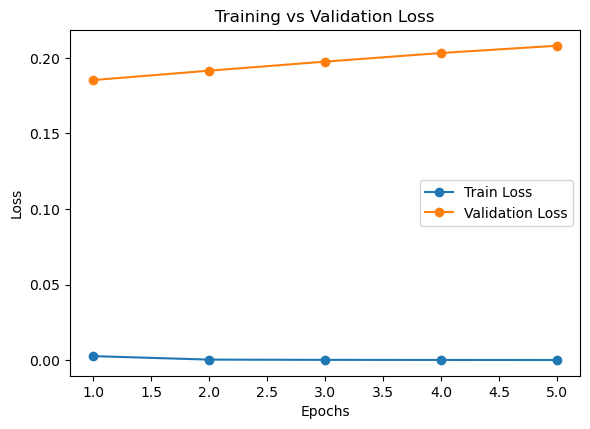

In [35]:
# ✅ Loss Graph (BOTTOM)
plt.figure(figsize=(6,8))

plt.subplot(2,1,2)
plt.plot(epochs_range, train_losses[0:5], marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses[0:5], marker='o', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()